# Temperature Trajectories by TTM Group Across Datasets

This notebook generates a supplementary figure showing hourly mean temperature trajectories
for TTM vs no-TTM patients across the four datasets used in the manuscript:

- **HYPERION** (RCT, France) — TTM from randomization arm, per-day temperature columns
- **eICU-CRD** (US multicenter) — TTM from treatment string + temperature derived; temperature from nurseCharting
- **MIMIC-IV** (BIDMC) — TTM from cooling-device itemid 225052; temperature from chartevents itemid 223761/223762
- **PMAP / OSLER** (JHU) — TTM from Fahrenheit temperature rule; temperature from Epic flowsheet meas_id 6

## How to run this
Each dataset section is self-contained and can be run on the machine where that dataset lives.
Each section produces a small aggregated CSV (`ts_<dataset>.csv`) with group-hour summaries — no PHI.
Once all four CSVs exist, run the final plotting section to produce the figure.

**Paths you may need to edit** are collected in the config cell below.



## 0. Config and imports

In [11]:
# Paths — edit per machine you run this on
EICU_DB         = '/projects/LCICM/eICU/'                  # contains nurseCharting.csv
EICU_PREDICTORS = './eICU/eICUPredictorsDiag.csv'              # your saved feature table with 'both_hypothermia'
EICU_IDS        = './eICU/patient_ids.csv'                        # same file you already use

MIMIC_DB         = '/projects/LCICM/'                      # contains mimic-iv-2.2/icu/chartevents.csv
MIMIC_CA_TIME    = './mimiciv/CA_time.csv'                           # cardiac arrest reference time
MIMIC_PREDICTORS = './mimiciv/MIMIC_Predictors2.csv'            # your saved feature table with 'hypothermia'
MIMIC_CA_ED = './mimiciv/CA_ED.csv' 

PMAP_DB          = '/projects/LCICM/ACCMPMAP/'             # contains Isalis/Isalis_Flowsheet*.csv
PMAP_PREDICTORS  = './pmap/PMAP_Predictors2.csv'             # your saved feature table with 'hypothermia'
PMAP_OHCA        = './pmap/ohca.csv'                            # for admission time reference

# HYPERION_CSV     = './hyperion.csv'                        # the trial CSV with J0_TEMP, J1_TEMP, BIO_TEMP, groupe
# HYPERION_GROUP_COL = 'groupe'                              # 1 = TTM, 2 = normothermia (confirm with Lascarrou)

# Analysis parameters
MAX_HOURS  = 72     # analysis horizon
BIN_HOURS  = 1      # hourly bins
OUTPUT_DIR = './timeseries_output'
import sys

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


## 1. Shared utilities

In [3]:
def to_celsius(series):
    """Convert to numeric °C, assuming values >50 are Fahrenheit."""
    s = pd.to_numeric(series, errors='coerce')
    is_f = s > 50
    s = s.where(~is_f, (s - 32) * 5.0 / 9.0)
    return s


def bin_hourly(df, id_col, ttm_col, time_min_col, temp_c_col, max_hours=MAX_HOURS):
    """Per-patient, per-hour mean temperature over [0, max_hours]."""
    d = df[[id_col, ttm_col, time_min_col, temp_c_col]].copy()
    d = d.rename(columns={id_col:'id', ttm_col:'ttm',
                          time_min_col:'t_min', temp_c_col:'temp_c'})
    d['temp_c'] = pd.to_numeric(d['temp_c'], errors='coerce')
    d['t_min']  = pd.to_numeric(d['t_min'], errors='coerce')
    d = d.dropna(subset=['temp_c','t_min'])
    d = d[(d['temp_c']>=25) & (d['temp_c']<=42)]
    d = d[(d['t_min']>=0) & (d['t_min']<=max_hours*60)]
    d['hour'] = (d['t_min']//60).astype(int)
    return (d.groupby(['id','ttm','hour'], as_index=False)['temp_c'].mean())


def summarize(hourly_long, dataset):
    """Aggregate patient-hours to group-hour summary (mean, median, IQR, n)."""
    agg = (hourly_long.groupby(['ttm','hour'])['temp_c']
           .agg(mean='mean',
                median='median',
                q25=lambda x: np.nanpercentile(x, 25),
                q75=lambda x: np.nanpercentile(x, 75),
                n='count')
           .reset_index())
    agg.insert(0,'dataset',dataset)
    return agg


## 2. HYPERION

HYPERION stores temperatures as per-day columns (`J0_TEMP`, `J1_TEMP`, ... `J5_TEMP` or similar).
We expand each daily column into a long row with hour = day * 24. If your data has more
granular temperature timestamps in a separate file, substitute that file here instead.

**TTM label**: `groupe == 1` is the TTM arm. Confirm with the trial codebook before publishing.


In [20]:
def readDfs():
    read_path = './hyperion/formatteddata/'
    myDfs = {}
    for file in os.listdir(read_path):
        myDfs[file.split('.')[0]] = pd.read_csv(read_path + file)
    return myDfs

In [21]:
# ===== HYPERION temperature time series =====

def run_hyperion(predictors_csv=None, out_csv=None,
                 hyperion_dir='./hyperion',
                 analysis_functions_dir='../../analysisFunctions'):
    """
    HYPERION has a dedicated time-series table `h0h64` recording temperature
    and other vitals every 2 hours from randomization to hour 64.
    """
    # Add the analysisFunctions directory to sys.path so we can import hyperion_utils
    af_dir = os.path.abspath(analysis_functions_dir)
    if af_dir not in sys.path:
        sys.path.insert(0, af_dir)
    # from hyperion_utils import readDfs

    # Load the raw trial tables
    myDfs = readDfs()

    # Temperature time-series table (every 2 hours, randomization -> hour 64)
    ts = myDfs['h0h64'][['SUBJID', 'H', 'H0H64_TEMP']].copy()
    ts['H']          = pd.to_numeric(ts['H'], errors='coerce')
    ts['H0H64_TEMP'] = pd.to_numeric(ts['H0H64_TEMP'], errors='coerce')
    ts = ts.dropna(subset=['H', 'H0H64_TEMP'])
    ts = ts[(ts['H'] >= 0) & (ts['H'] <= MAX_HOURS)]

    # Randomization arm: groupe == 1 is TTM, groupe == 2 is normothermia
    rando = myDfs['bras_rando'][['SUBJID', 'groupe']].dropna(subset=['groupe'])
    rando['ttm'] = (rando['groupe'] == 1).astype(int)
    print(f"HYPERION randomization counts: "
          f"TTM={int(rando['ttm'].sum())}, "
          f"no-TTM={int((rando['ttm']==0).sum())}")

    if predictors_csv and os.path.exists(predictors_csv):
        preds = pd.read_csv(predictors_csv, usecols=['SUBJID'])
        rando = rando[rando['SUBJID'].isin(preds['SUBJID'])]
        print(f"After restricting to analytic cohort: n={rando['SUBJID'].nunique()}")

    df = ts.merge(rando[['SUBJID', 'ttm']], on='SUBJID', how='inner')
    df = df.rename(columns={'H0H64_TEMP': 'temp_c', 'SUBJID': 'id'})
    df['temp_c'] = to_celsius(df['temp_c'])
    df = df.dropna(subset=['temp_c'])
    df = df[(df['temp_c'] >= 25) & (df['temp_c'] <= 42)]
    df['hour'] = df['H'].round().astype(int)

    hourly = df.groupby(['id', 'ttm', 'hour'], as_index=False)['temp_c'].mean()

    summary = summarize(hourly, 'HYPERION')
    out_path = out_csv or f'{OUTPUT_DIR}/ts_hyperion.csv'
    summary.to_csv(out_path, index=False)
    print(f'Wrote {out_path} ({len(summary)} rows)')
    print(f'Hours represented: {sorted(summary["hour"].unique())}')
    return summary


summary_hyp = run_hyperion(hyperion_dir='./hyperion',
                           analysis_functions_dir='../../analysisFunctions')

HYPERION randomization counts: TTM=287, no-TTM=297
Wrote ./timeseries_output/ts_hyperion.csv (66 rows)
Hours represented: [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(32), np.int64(34), np.int64(36), np.int64(38), np.int64(40), np.int64(42), np.int64(44), np.int64(46), np.int64(48), np.int64(50), np.int64(52), np.int64(54), np.int64(56), np.int64(58), np.int64(60), np.int64(62), np.int64(64)]


## 3. eICU-CRD

Temperature comes from `nurseCharting.csv` where `nursingchartcelltypevalname == "Temperature (C)"`.
Time offset is `nursingchartentryoffset` (minutes from ICU admission).

**TTM label**: the `both_hypothermia` flag in your saved `myPredictorsDf` (treatment-string OR
temperature-derived, per eICU__1_.ipynb). This matches the definition in the paper.


In [6]:
def run_eicu(db=EICU_DB, predictors_csv=EICU_PREDICTORS, ids_csv=EICU_IDS):
    preds = pd.read_csv(predictors_csv, usecols=['patientunitstayid','both_hypothermia'])
    preds = preds.rename(columns={'both_hypothermia':'ttm'})

    # If you have an IDs file, restrict; otherwise use all predictor IDs
    try:
        ids = pd.read_csv(ids_csv).patientunitstayid.unique()
        preds = preds[preds.patientunitstayid.isin(ids)]
    except FileNotFoundError:
        pass

    print(f'eICU analytic cohort: n={preds.patientunitstayid.nunique()}')

    chunks = []
    file_path = db + 'nurseCharting.csv'
    for chunk in tqdm(pd.read_csv(file_path, chunksize=1_000_000,
                                  usecols=['patientunitstayid',
                                           'nursingchartentryoffset',
                                           'nursingchartcelltypevalname',
                                           'nursingchartvalue'])):
        chunk = chunk[chunk['nursingchartcelltypevalname']=='Temperature (C)']
        chunk = chunk[chunk['patientunitstayid'].isin(preds.patientunitstayid)]
        if len(chunk):
            chunks.append(chunk)
    raw = pd.concat(chunks, ignore_index=True)
    raw = raw.merge(preds, on='patientunitstayid', how='inner')
    raw['temp_c'] = to_celsius(raw['nursingchartvalue'])

    hourly = bin_hourly(raw, 'patientunitstayid', 'ttm',
                        'nursingchartentryoffset', 'temp_c')
    summary = summarize(hourly, 'eICU')
    out_path = f'{OUTPUT_DIR}/ts_eicu.csv'
    summary.to_csv(out_path, index=False)
    print(f'Wrote {out_path} ({len(summary)} rows)')
    return summary

summary_eicu = run_eicu()   # uncomment to run


eICU analytic cohort: n=3172


10it [00:08,  1.22it/s]

13it [00:10,  1.24it/s]

## 4. MIMIC-IV

Temperature itemids in MIMIC-IV:
- `223761` — Temperature Fahrenheit
- `223762` — Temperature Celsius

Time offset is `chartoffset` (minutes from arrest reference time, per Feature_extraction.ipynb
convention where chartoffset is computed as `charttime - ca_time`).

**TTM label**: `hypothermia` flag in your saved `myPredictorsDf`, derived from cooling device
itemid 225052 being "On" continuously for ≥720 minutes.


In [6]:
MIMIC_TEMP_ITEMIDS = [223761, 223762]

def _build_ca_reference_time(ca_ed_csv, ca_time_csv):
    """Replicates the feature extraction notebook:
       ca_ed_df['time'] = ca_ed_df['intime']
       ca_time_df['time'] = ca_time_df['max_time']
       Then concatenate and keep one row per (subject_id, hadm_id).
    """
    ca_ed = pd.read_csv(ca_ed_csv)
    ca_time = pd.read_csv(ca_time_csv)
    ca_ed['time']   = ca_ed['intime']
    ca_time['time'] = ca_time['max_time']
    keep_cols = ['subject_id','hadm_id','time']
    ca_df = pd.concat([ca_ed[keep_cols], ca_time[keep_cols]], ignore_index=True)
    ca_df = ca_df.sort_values(['subject_id','hadm_id']).drop_duplicates(['subject_id','hadm_id'])
    # collapse to one reference time per subject_id (use earliest)
    ca_df['time'] = pd.to_datetime(ca_df['time'], errors='coerce')
    ca_df = (ca_df.dropna(subset=['time'])
                  .sort_values('time')
                  .drop_duplicates('subject_id', keep='first'))
    return ca_df[['subject_id','time']]


def run_mimic(db=MIMIC_DB, predictors_csv=MIMIC_PREDICTORS,
              ca_ed_csv=MIMIC_CA_ED, ca_time_csv=MIMIC_CA_TIME):
    preds = pd.read_csv(predictors_csv, usecols=['subject_id','hypothermia'])
    preds = preds.rename(columns={'hypothermia':'ttm'})

    ca_ref = _build_ca_reference_time(ca_ed_csv, ca_time_csv)
    print(f'MIMIC analytic cohort: n={preds.subject_id.nunique()}')
    print(f'MIMIC reference times available: n={ca_ref.subject_id.nunique()}')

    chunks = []
    file_path = db + 'mimic-iv-2.2/icu/chartevents.csv'
    usecols = ['subject_id','charttime','itemid','valuenum','value']
    for chunk in tqdm(pd.read_csv(file_path, chunksize=1_000_000, usecols=usecols)):
        chunk = chunk[chunk['itemid'].isin(MIMIC_TEMP_ITEMIDS)]
        chunk = chunk[chunk['subject_id'].isin(preds.subject_id)]
        if len(chunk):
            chunks.append(chunk)
    raw = pd.concat(chunks, ignore_index=True)
    raw = raw.merge(ca_ref, on='subject_id', how='left')
    raw['charttime']   = pd.to_datetime(raw['charttime'], errors='coerce')
    raw['chartoffset'] = (raw['charttime'] - raw['time']).dt.total_seconds() / 60
    raw = raw[raw['chartoffset']>=0]
    raw = raw.merge(preds, on='subject_id', how='inner')

    # valuenum preferred; fall back to parsing 'value'
    raw['temp_c'] = to_celsius(raw['valuenum'].fillna(raw['value']))

    hourly = bin_hourly(raw, 'subject_id', 'ttm', 'chartoffset', 'temp_c')
    summary = summarize(hourly, 'MIMIC-IV')
    out_path = f'{OUTPUT_DIR}/ts_mimic.csv'
    summary.to_csv(out_path, index=False)
    print(f'Wrote {out_path} ({len(summary)} rows)')
    return summary

summary_mimic = run_mimic()

MIMIC analytic cohort: n=743
MIMIC reference times available: n=987


314it [06:05,  1.16s/it]


Wrote ./timeseries_output/ts_mimic.csv (146 rows)


## 5. PMAP (JHU OSLER/Epic)

Temperature `meas_id` values, per Feature_extraction__1_.ipynb:
- `6`
- `304301490`

Time offset is `meas_offset` in minutes from hospital admission
(computed from `recorded_time - hosp_admsn_time`).

**TTM label**: `hypothermia` flag in your saved `myPredictorsDf`, derived from average first-24h
temperature <96.8°F (≈36°C) with minimum ≥77°F (≈25°C).


In [8]:
PMAP_TEMP_MEAS_IDS = [6, 304301490]

FLOWSHEET_COLS = ['osler_id','pat_enc_csn_id','inpatient_data_id','recorded_time','meas_value',
                  'meas_comment','meas_id','meas_row_type_c','meas_val_type_c','meas_template_id',
                  'meas_fsd_id','meas_line','meas_occurance','rw_meas_id',
                  'ip_lda_id','rw_row_type_c','rw_val_type_c','meas_taken_user_id']

def read_flowsheet_filtered(file_path, keep_osler_ids, keep_meas_ids,
                            chunk_size=500_000, head=None):
    """Read flowsheet in chunks, filter per-chunk, concatenate only what we keep.
    Also keeps only the columns we actually need downstream to reduce memory further."""
    keep_cols_out = ['osler_id', 'recorded_time', 'meas_value', 'meas_id']
    kept = []
    n_rows_scanned = 0
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, header=head,
                             low_memory=False):
        chunk.columns = FLOWSHEET_COLS
        # filter BEFORE appending — this is the key
        chunk = chunk[chunk['meas_id'].isin(keep_meas_ids)]
        chunk = chunk[chunk['osler_id'].isin(keep_osler_ids)]
        if len(chunk):
            kept.append(chunk[keep_cols_out].copy())
        n_rows_scanned += chunk_size
        if n_rows_scanned % (chunk_size * 10) == 0:
            kept_so_far = sum(len(x) for x in kept)
            print(f'  scanned ~{n_rows_scanned:,} rows, kept {kept_so_far:,}')
    if not kept:
        return pd.DataFrame(columns=keep_cols_out)
    return pd.concat(kept, ignore_index=True)


def run_pmap(db=PMAP_DB, predictors_csv=PMAP_PREDICTORS, ohca_csv=PMAP_OHCA):
    preds = pd.read_csv(predictors_csv, usecols=['osler_id', 'hypothermia'])
    preds = preds.rename(columns={'hypothermia': 'ttm'})
    ohca = pd.read_csv(ohca_csv, usecols=['osler_id', 'hosp_admsn_time'])

    keep_osler_ids = set(preds['osler_id'].unique())
    keep_meas_ids  = set(PMAP_TEMP_MEAS_IDS)
    print(f'PMAP analytic cohort: n={len(keep_osler_ids)}')

    parts = []
    for fname in ['Isalis/Isalis_Flowsheet_part1.csv',
                  'Isalis/Isalis_Flowsheet_part2.csv',
                  'Isalis/Isalis_Flowsheetdata.csv']:
        p = db + fname
        print(f'Reading {p}')
        parts.append(read_flowsheet_filtered(p, keep_osler_ids, keep_meas_ids))
    flow = pd.concat(parts, ignore_index=True)
    del parts
    print(f'Temperature rows kept across all files: {len(flow):,}')

    # compute meas_offset in minutes from hospital admission
    flow = flow.merge(ohca, on='osler_id', how='left')
    flow['recorded_time']   = pd.to_datetime(flow['recorded_time'], errors='coerce')
    flow['hosp_admsn_time'] = pd.to_datetime(flow['hosp_admsn_time'], errors='coerce')
    flow['meas_offset']     = (flow['recorded_time'] - flow['hosp_admsn_time']).dt.total_seconds() / 60
    flow = flow[flow['meas_offset'] >= 0]

    flow = flow.merge(preds, on='osler_id', how='inner')
    flow['temp_c'] = to_celsius(flow['meas_value'])

    hourly = bin_hourly(flow, 'osler_id', 'ttm', 'meas_offset', 'temp_c')
    summary = summarize(hourly, 'PMAP')
    out_path = f'{OUTPUT_DIR}/ts_pmap.csv'
    summary.to_csv(out_path, index=False)
    print(f'Wrote {out_path} ({len(summary)} rows)')
    return summary

summary_pmap = run_pmap()

PMAP analytic cohort: n=1741
Reading /projects/LCICM/ACCMPMAP/Isalis/Isalis_Flowsheet_part1.csv
  scanned ~5,000,000 rows, kept 20,809
  scanned ~10,000,000 rows, kept 41,359
  scanned ~15,000,000 rows, kept 62,038
  scanned ~20,000,000 rows, kept 83,097
  scanned ~25,000,000 rows, kept 103,808
  scanned ~30,000,000 rows, kept 124,402
  scanned ~35,000,000 rows, kept 144,986
  scanned ~40,000,000 rows, kept 165,699
  scanned ~45,000,000 rows, kept 186,405
  scanned ~50,000,000 rows, kept 207,106
  scanned ~55,000,000 rows, kept 227,748
  scanned ~60,000,000 rows, kept 248,364
  scanned ~65,000,000 rows, kept 268,887
Reading /projects/LCICM/ACCMPMAP/Isalis/Isalis_Flowsheet_part2.csv
  scanned ~5,000,000 rows, kept 21,092
  scanned ~10,000,000 rows, kept 42,499
  scanned ~15,000,000 rows, kept 63,582
  scanned ~20,000,000 rows, kept 85,125
  scanned ~25,000,000 rows, kept 106,165
  scanned ~30,000,000 rows, kept 127,162
  scanned ~35,000,000 rows, kept 148,597
  scanned ~40,000,000 rows,

## 6. Combine and plot

Run this after the four summary CSVs exist. It produces a 2x2 panel figure ready for the
supplement. The plot format matches typical ICM supplement style.


Wrote supp_fig_temperature_trajectories.png and supp_fig_temperature_trajectories.pdf


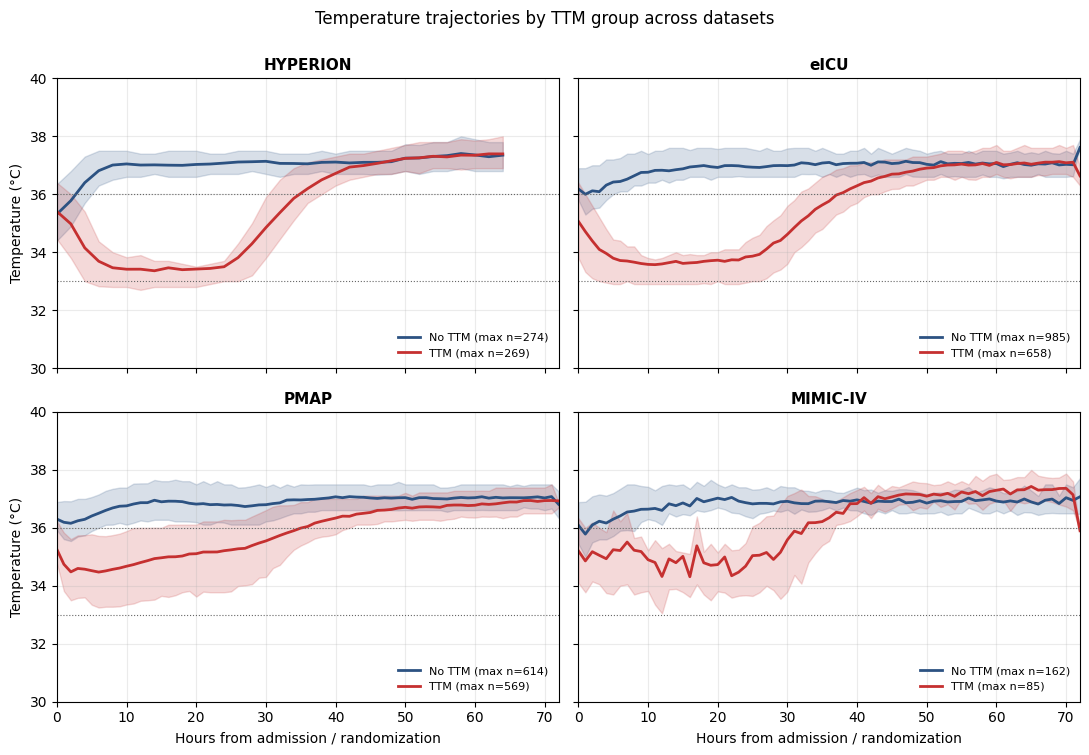

In [23]:
import matplotlib.pyplot as plt

def plot_trajectories(output_dir=OUTPUT_DIR,
                      out_png='supp_fig_temperature_trajectories.png',
                      out_pdf='supp_fig_temperature_trajectories.pdf'):
    files = {
        'HYPERION': f'{output_dir}/ts_hyperion.csv',
        'eICU':     f'{output_dir}/ts_eicu.csv',
        'PMAP':     f'{output_dir}/ts_pmap.csv',
        'MIMIC-IV': f'{output_dir}/ts_mimic.csv',
    }
    loaded = {}
    for name, path in files.items():
        try:
            loaded[name] = pd.read_csv(path)
        except FileNotFoundError:
            print(f'  (missing: {path})')

    fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), sharex=True, sharey=True)
    colors = {0: '#2c5282', 1: '#c53030'}   # blue no-TTM, red TTM
    labels = {0: 'No TTM', 1: 'TTM'}

    panel_order = ['HYPERION', 'eICU', 'PMAP', 'MIMIC-IV']
    for ax, name in zip(axes.ravel(), panel_order):
        if name not in loaded:
            ax.set_title(f'{name} (no data)', fontsize=10)
            ax.axis('off')
            continue
        sub = loaded[name]
        for ttm_val in [0, 1]:
            g = sub[sub['ttm']==ttm_val].sort_values('hour')
            if g.empty:
                continue
            ax.plot(g['hour'], g['mean'], color=colors[ttm_val], lw=2,
                    label=f'{labels[ttm_val]} (max n={int(g["n"].max())})')
            ax.fill_between(g['hour'], g['q25'], g['q75'],
                            color=colors[ttm_val], alpha=0.18)
        ax.axhline(33, ls=':', color='#666', lw=0.8)
        ax.axhline(36, ls=':', color='#666', lw=0.8)
        ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_ylim(30, 40)
        ax.set_xlim(0, MAX_HOURS)
        ax.legend(loc='lower right', fontsize=8, frameon=False)
        ax.grid(alpha=0.25)

    for ax in axes[-1]:
        ax.set_xlabel('Hours from admission / randomization')
    for ax in axes[:,0]:
        ax.set_ylabel('Temperature (°C)')

    fig.suptitle('Temperature trajectories by TTM group across datasets',
                 fontsize=12, y=1.00)
    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    print(f'Wrote {out_png} and {out_pdf}')
    return fig

fig = plot_trajectories()


## 7. Optional: companion table of per-group minimum temperatures

Quantifies the clinical construct-validity argument numerically. Useful as Supplementary Table S20
or as a 2-row note under the figure.


In [24]:
def nadir_table(output_dir=OUTPUT_DIR):
    rows = []
    for name, path in [('HYPERION', 'ts_hyperion.csv'),
                       ('eICU',     'ts_eicu.csv'),
                       ('PMAP',     'ts_pmap.csv'),
                       ('MIMIC-IV', 'ts_mimic.csv')]:
        try:
            d = pd.read_csv(f'{output_dir}/{path}')
        except FileNotFoundError:
            continue
        for ttm_val in [0, 1]:
            sub = d[d['ttm']==ttm_val]
            if sub.empty:
                continue
            nadir_row = sub.loc[sub['mean'].idxmin()]
            rows.append({
                'Dataset':      name,
                'Group':        'TTM' if ttm_val==1 else 'No TTM',
                'Nadir (°C)':   round(nadir_row['mean'], 2),
                'Hour of nadir': int(nadir_row['hour']),
                'IQR at nadir': f"[{nadir_row['q25']:.2f}, {nadir_row['q75']:.2f}]",
                'n at nadir':   int(nadir_row['n']),
            })
    out = pd.DataFrame(rows)
    out.to_csv(f'{output_dir}/nadir_table.csv', index=False)
    print(out.to_string(index=False))
    return out

nadir_tbl = nadir_table()


 Dataset  Group  Nadir (°C)  Hour of nadir   IQR at nadir  n at nadir
HYPERION No TTM       35.31              0 [34.40, 36.35]         271
HYPERION    TTM       33.36             14 [32.80, 33.70]         253
    eICU No TTM       36.00              1 [35.30, 36.90]         635
    eICU    TTM       33.57             11 [32.90, 33.75]         630
    PMAP No TTM       36.16              2 [35.55, 36.92]         448
    PMAP    TTM       34.47              6 [33.25, 35.72]         541
MIMIC-IV No TTM       35.78              1 [35.00, 36.90]         137
MIMIC-IV    TTM       34.31             16 [33.61, 35.10]          19
